# 02 — Feature EDA: Engineered Features, Correlation, and Seasonality

Spec: `specs/003-complete-forecasting-submission/spec.md` FR-29 (correlation/seasonality via notebook), FR-30–FR-34.

This notebook **displays already-generated artifacts**; it does not recompute correlation, SHAP,
metrics, or figures inline (spec 003 T012 constraint). All figures shown here were produced by
`src/report_assets.py` (T011) and written to `outputs/figures/`. Any tabular context below is
loaded directly from `data/processed/featured.parquet`, produced by `src/features.py` (spec 001),
imported only for column names / shared constants — no feature recomputation happens in this
notebook.


In [1]:
import sys
from pathlib import Path

# Ensure repo root is on sys.path so `from src...` imports resolve regardless of the
# notebook's working directory (nbconvert executes with cwd = notebooks/).
_repo_root = Path.cwd()
if not (_repo_root / "src").exists():
    _repo_root = _repo_root.parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))
import os
os.chdir(_repo_root)

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.features import FEATURED_PATH

FIGURES_DIR = Path("outputs/figures")
featured = pd.read_parquet(FEATURED_PATH)
print(f"Loaded {FEATURED_PATH}: {featured.shape[0]:,} rows x {featured.shape[1]} columns")


Loaded data/processed/featured.parquet: 1,095,257 rows x 30 columns


## 1. Engineered feature overview

Column names and dtypes as produced by `src/features.py::build_feature_set` (FR-29 context;
no business logic re-implemented here — this is a plain `.columns`/`.dtypes` display).

In [2]:
print(f"Columns ({len(featured.columns)}): {list(featured.columns)}")
print()
print("Dtypes:")
print(featured.dtypes)


Columns (30): ['ProductID', 'WeekStart', 'Sales_Qty', 'Sales_USD', 'returns_exceeded_sales', 'transaction_count', 'Region', 'Country', 'Sales Channel', 'Brand Category', 'Product Range', 'Sales_Qty_lag_1', 'Sales_Qty_lag_2', 'Sales_Qty_lag_4', 'Sales_Qty_lag_12', 'Sales_Qty_rollmean_4', 'Sales_Qty_rollstd_4', 'Sales_Qty_rollmean_12', 'Sales_Qty_rollstd_12', 'dominant_dow', 'pct_weekend_orders', 'month', 'week_of_month', 'quarter', 'week_of_year', 'is_year_end', 'is_lk_holiday_week', 'zero_streak_length', 'cumulative_zero_weeks', 'unit_price']

Dtypes:
ProductID                            str
WeekStart                 datetime64[us]
Sales_Qty                        float64
Sales_USD                        float64
returns_exceeded_sales              bool
transaction_count                  int64
Region                               str
Country                              str
Sales Channel                        str
Brand Category                       str
Product Range                   

## 2. Descriptive summary of numeric engineered features

Plain `.describe()` over the numeric engineered columns — a display of already-materialized data,
not a recomputation of any correlation/model logic.

In [3]:
numeric_cols = featured.select_dtypes(include="number").columns.tolist()
featured[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Sales_Qty,1095257.0,11.208651,167.042375,0.0,0.0,0.0,0.0,21671.0
Sales_USD,1095257.0,175.831543,2396.00389,-62049.0,0.0,0.0,0.0,239917.0
transaction_count,1095257.0,0.04656,0.225392,0.0,0.0,0.0,0.0,6.0
Sales_Qty_lag_1,1086205.0,11.267336,167.435039,0.0,0.0,0.0,0.0,21671.0
Sales_Qty_lag_2,1077165.0,11.319566,167.989831,0.0,0.0,0.0,0.0,21671.0
Sales_Qty_lag_4,1059157.0,11.365609,168.272579,0.0,0.0,0.0,0.0,21671.0
Sales_Qty_lag_12,988730.0,11.629214,170.879553,0.0,0.0,0.0,0.0,21671.0
Sales_Qty_rollmean_4,1086205.0,12.486935,112.391375,0.0,0.0,0.0,0.0,13165.0
Sales_Qty_rollstd_4,1077165.0,19.30931,154.03778,0.0,0.0,0.0,0.0,15137.741972
Sales_Qty_rollmean_12,1086205.0,13.733764,102.525239,0.0,0.0,0.0,3.75,13165.0


## 3. Correlation matrix (generated by `src/report_assets.py::fig_correlation_heatmap`)

Correlation heatmap over engineered numeric features (FR-29), generated by T011's
`src/report_assets.py` and saved to `outputs/figures/correlation_heatmap.png`. Loaded and
displayed here, not recomputed.

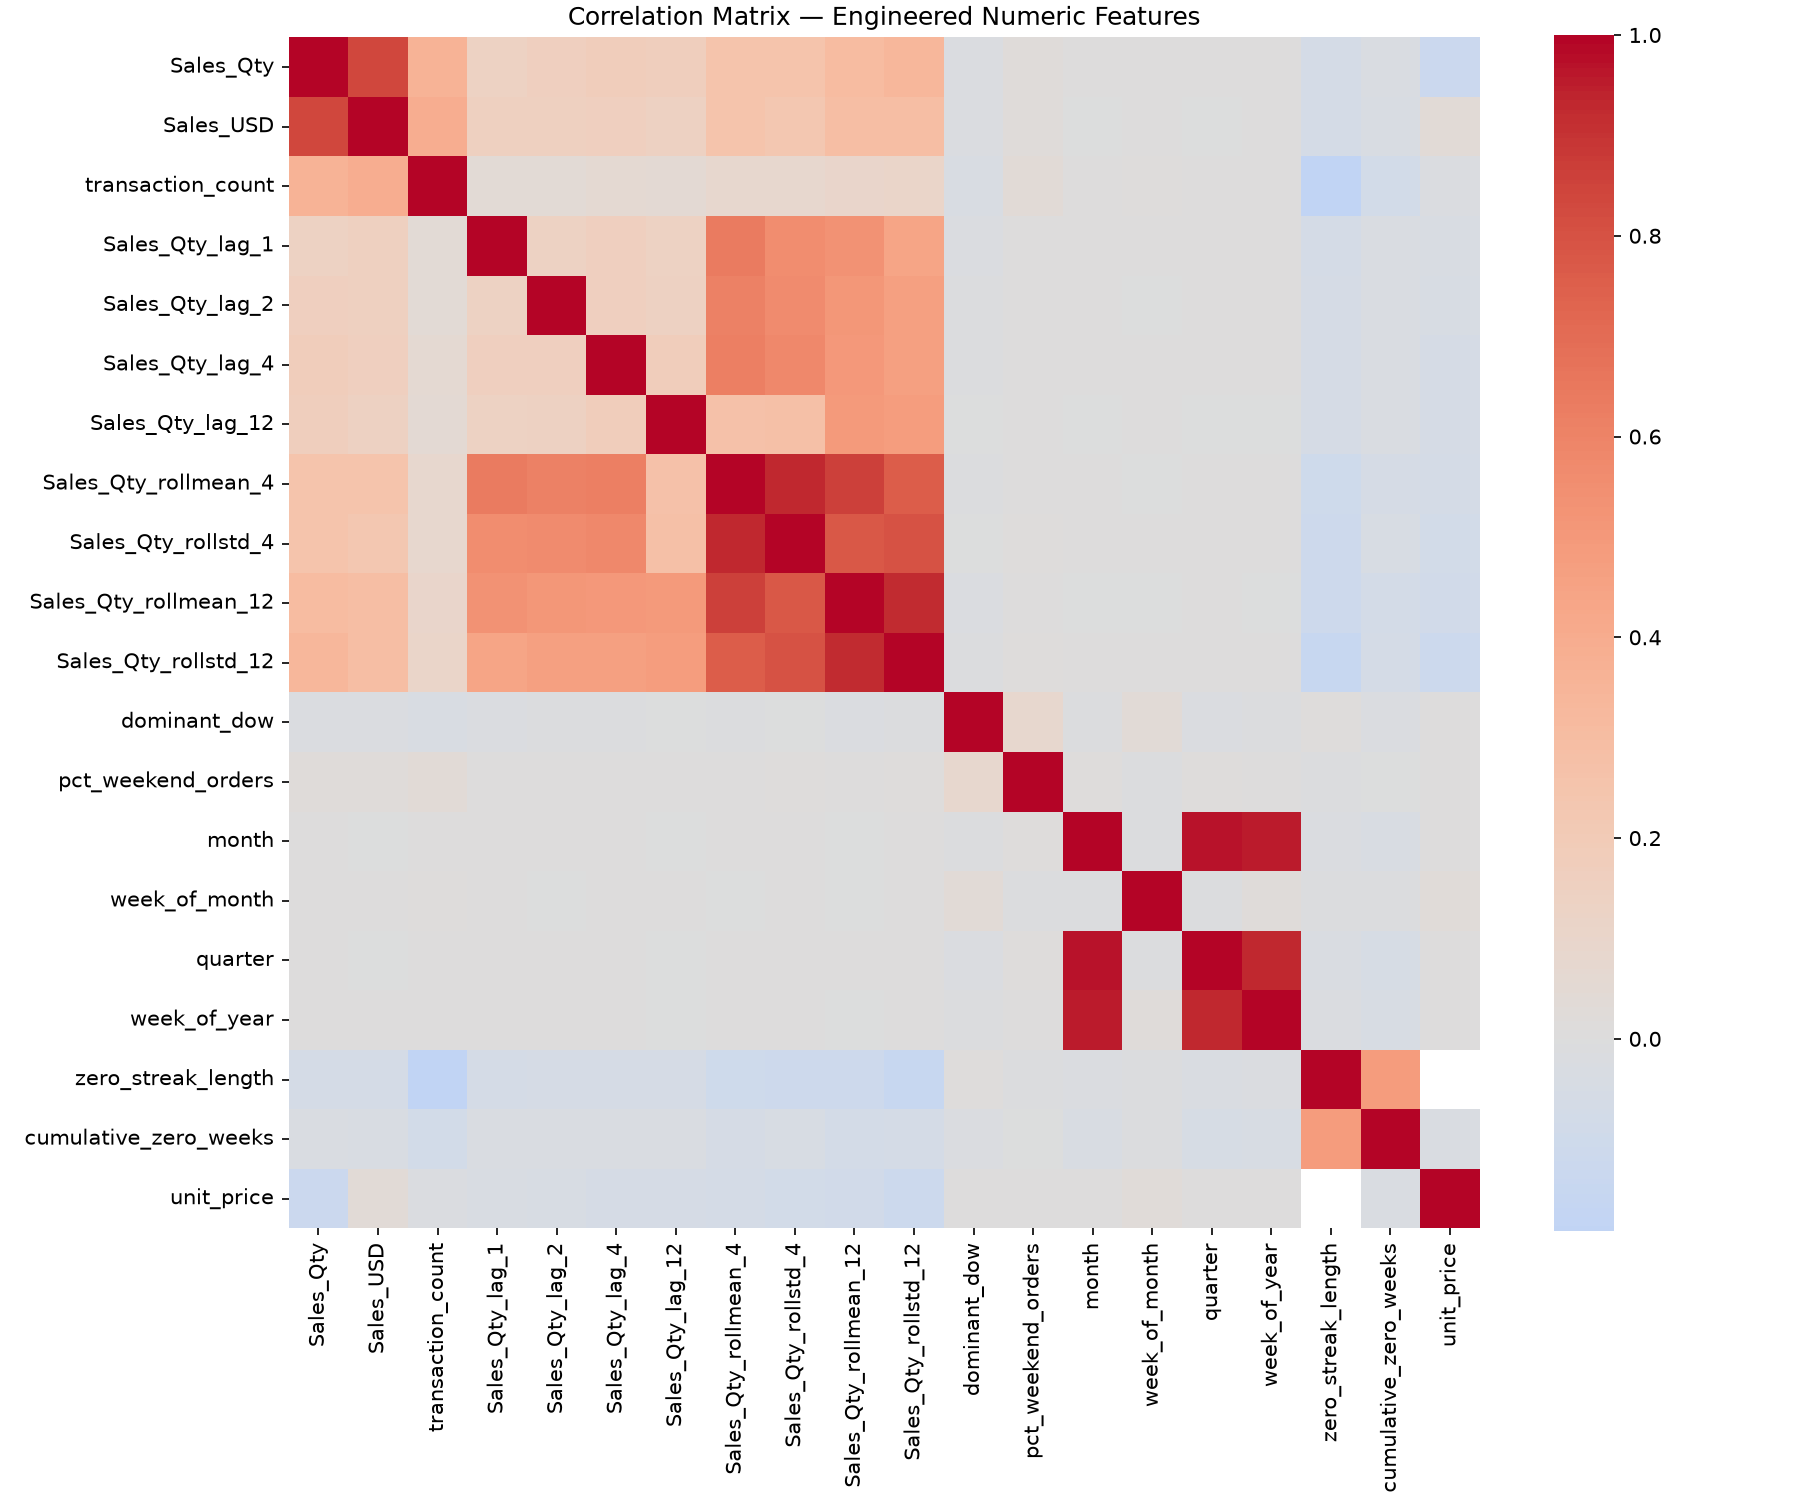

In [4]:
display(Image(filename=str(FIGURES_DIR / "correlation_heatmap.png")))


## 4. Sparse / zero-week distribution (generated by `src/report_assets.py::fig_sparse_zero_analysis`)

Zero-streak / zero-share distribution plot for the sparse tier (FR-33), generated by T011 and
saved to `outputs/figures/sparse_zero_analysis.png`.

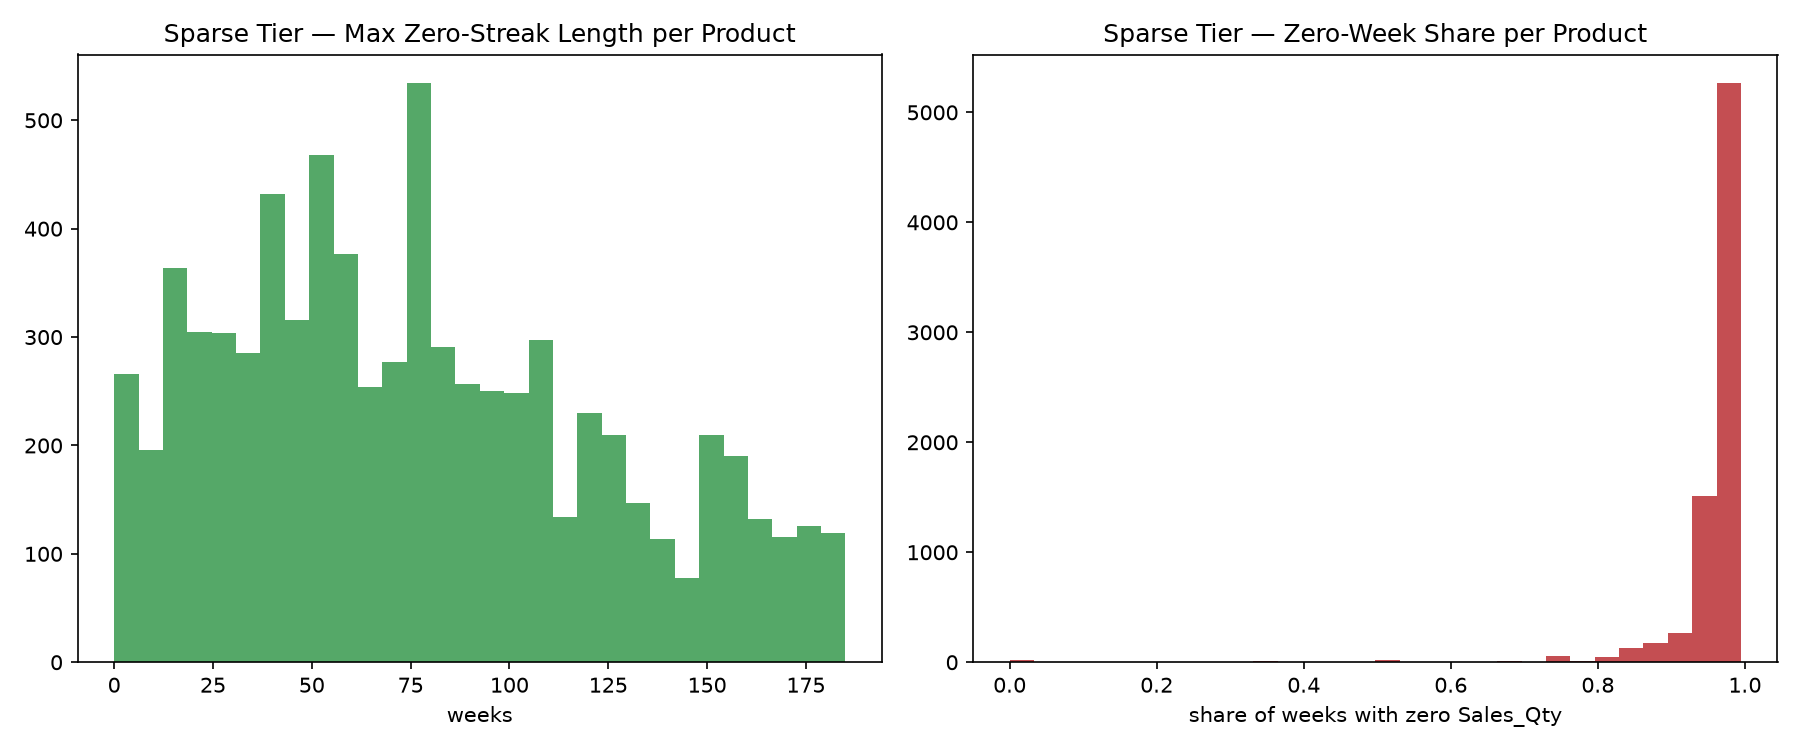

In [5]:
display(Image(filename=str(FIGURES_DIR / "sparse_zero_analysis.png")))


## 5. YoY trend and seasonal decomposition (top-volume products)

`src/report_assets.py::fig_yoy_seasonal_decomposition` (T011) selects the top-volume in-scope
products with >=104 weeks of history (2 full annual cycles) and generates:

- a year-over-year trend plot (`yoy_<ProductID>.png`)
- an additive `statsmodels.tsa.seasonal.seasonal_decompose(period=52)` plot
  (`seasonal_decompose_<ProductID>.png`)

for each. Products with less than 104 weeks of history are skipped there (logged reason), not
shown here. The generated product IDs are discovered by listing the actual files under
`outputs/figures/` — not hard-coded — so this cell stays in sync with whatever T011 produced.

In [6]:
seasonal_paths = sorted(FIGURES_DIR.glob("seasonal_decompose_*.png"))
yoy_paths = sorted(FIGURES_DIR.glob("yoy_*.png"))

product_ids = sorted(p.stem.replace("seasonal_decompose_", "") for p in seasonal_paths)
print(f"Top-volume products with >=104 weeks of history (seasonal decomposition + YoY shown): {product_ids}")


Top-volume products with >=104 weeks of history (seasonal decomposition + YoY shown): ['53064-028', '68877-087', '81509-047']


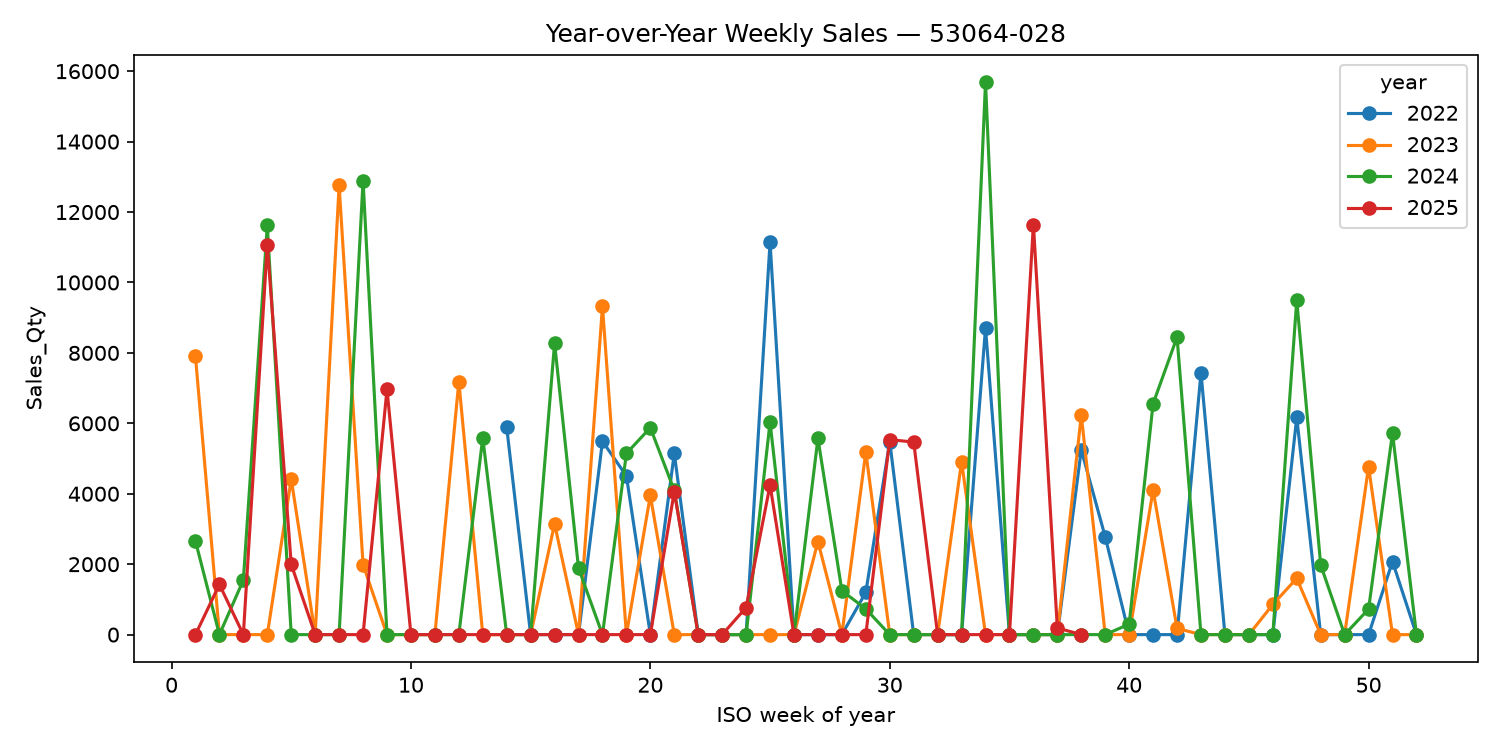

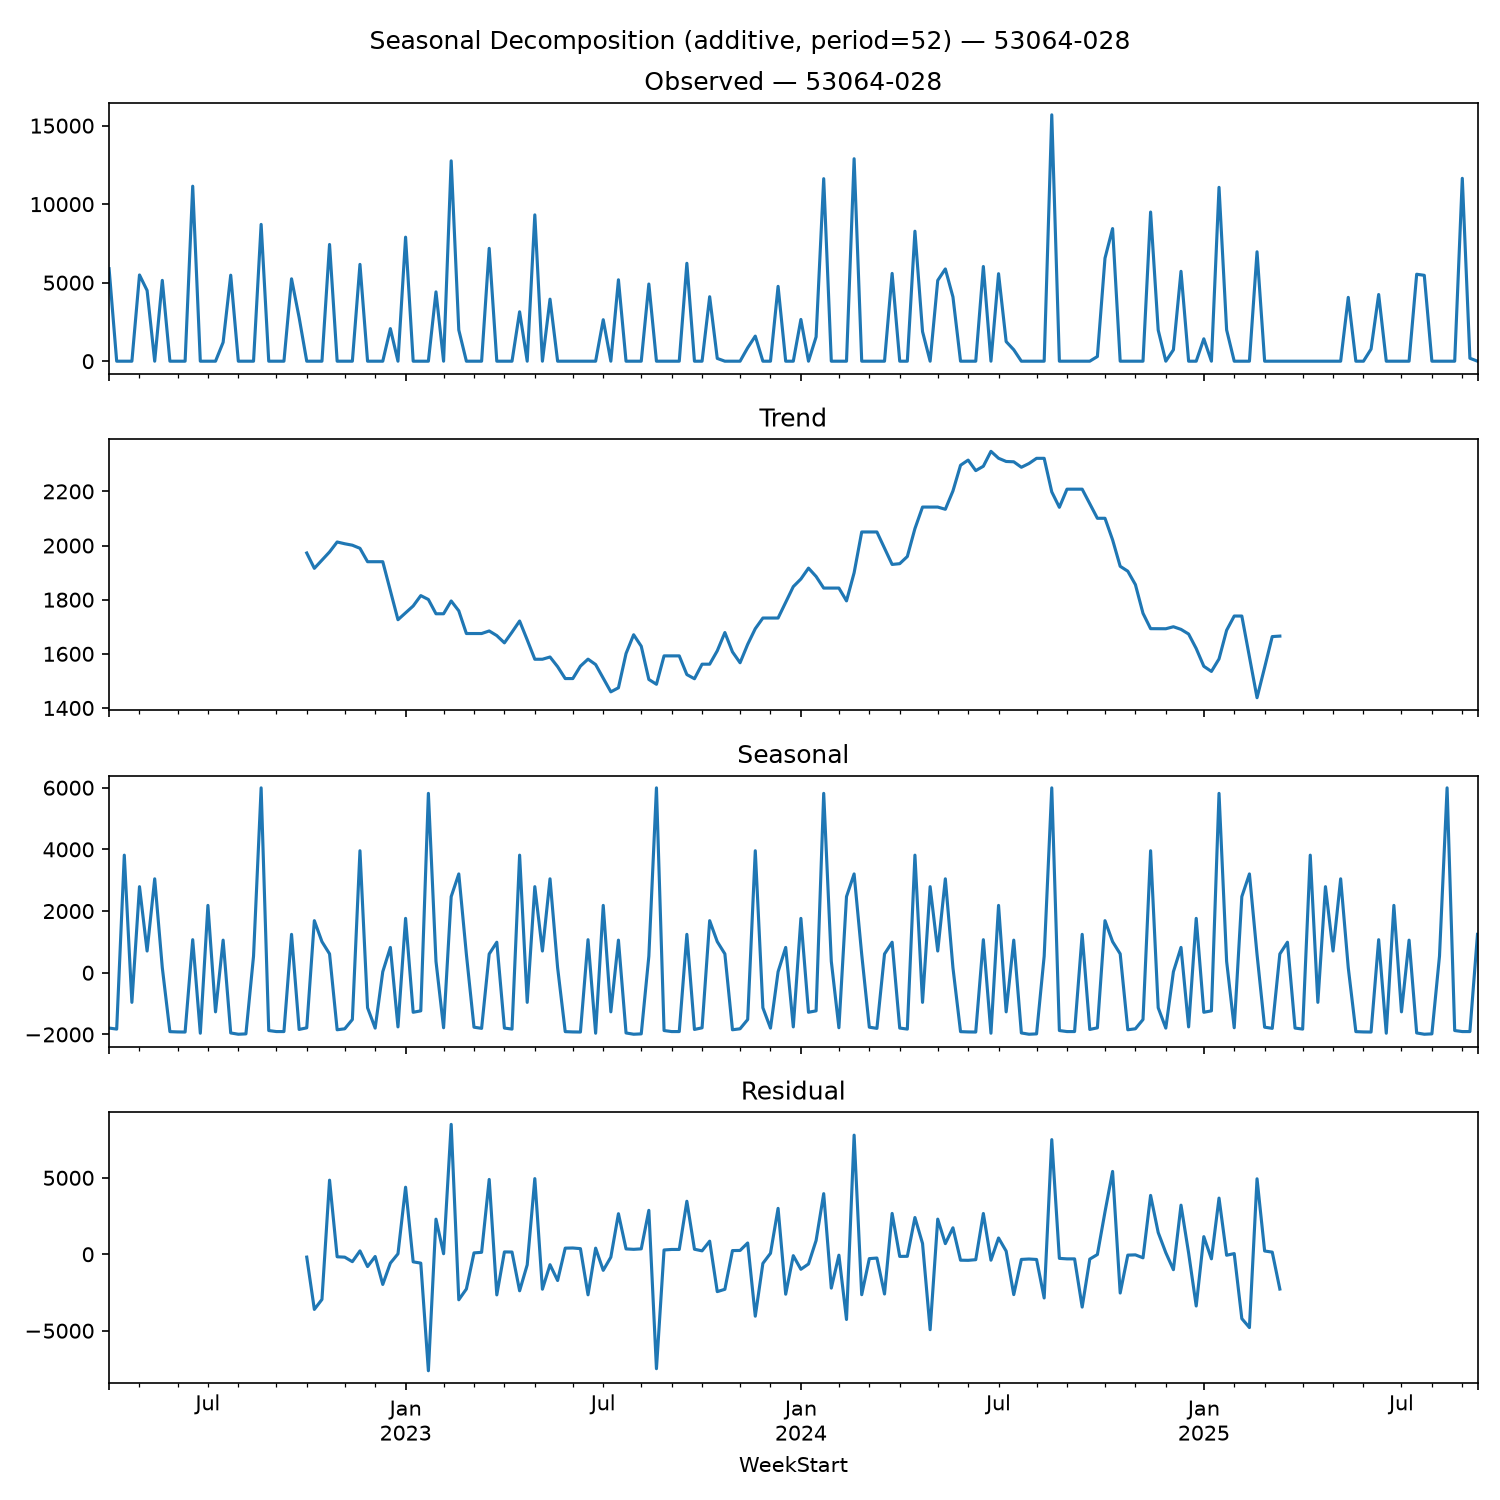

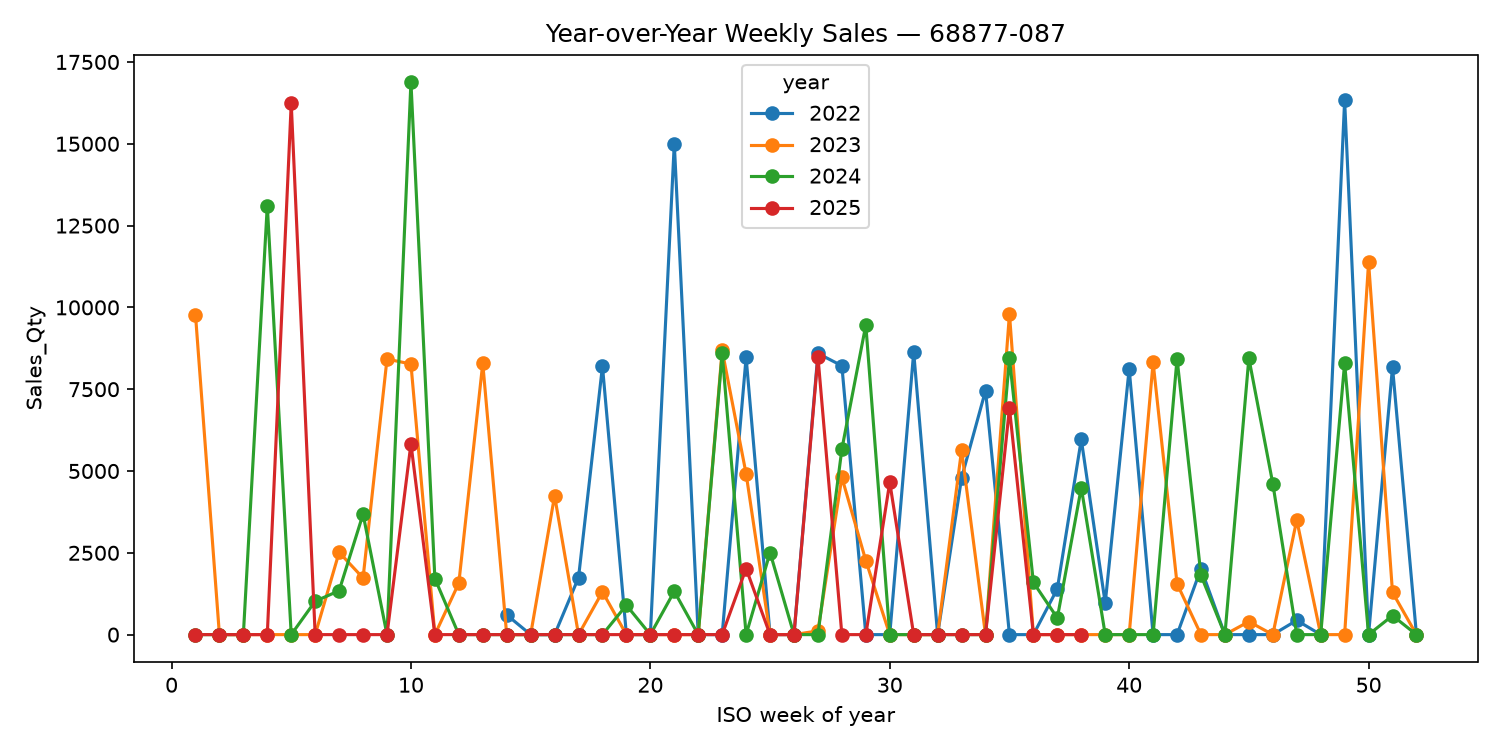

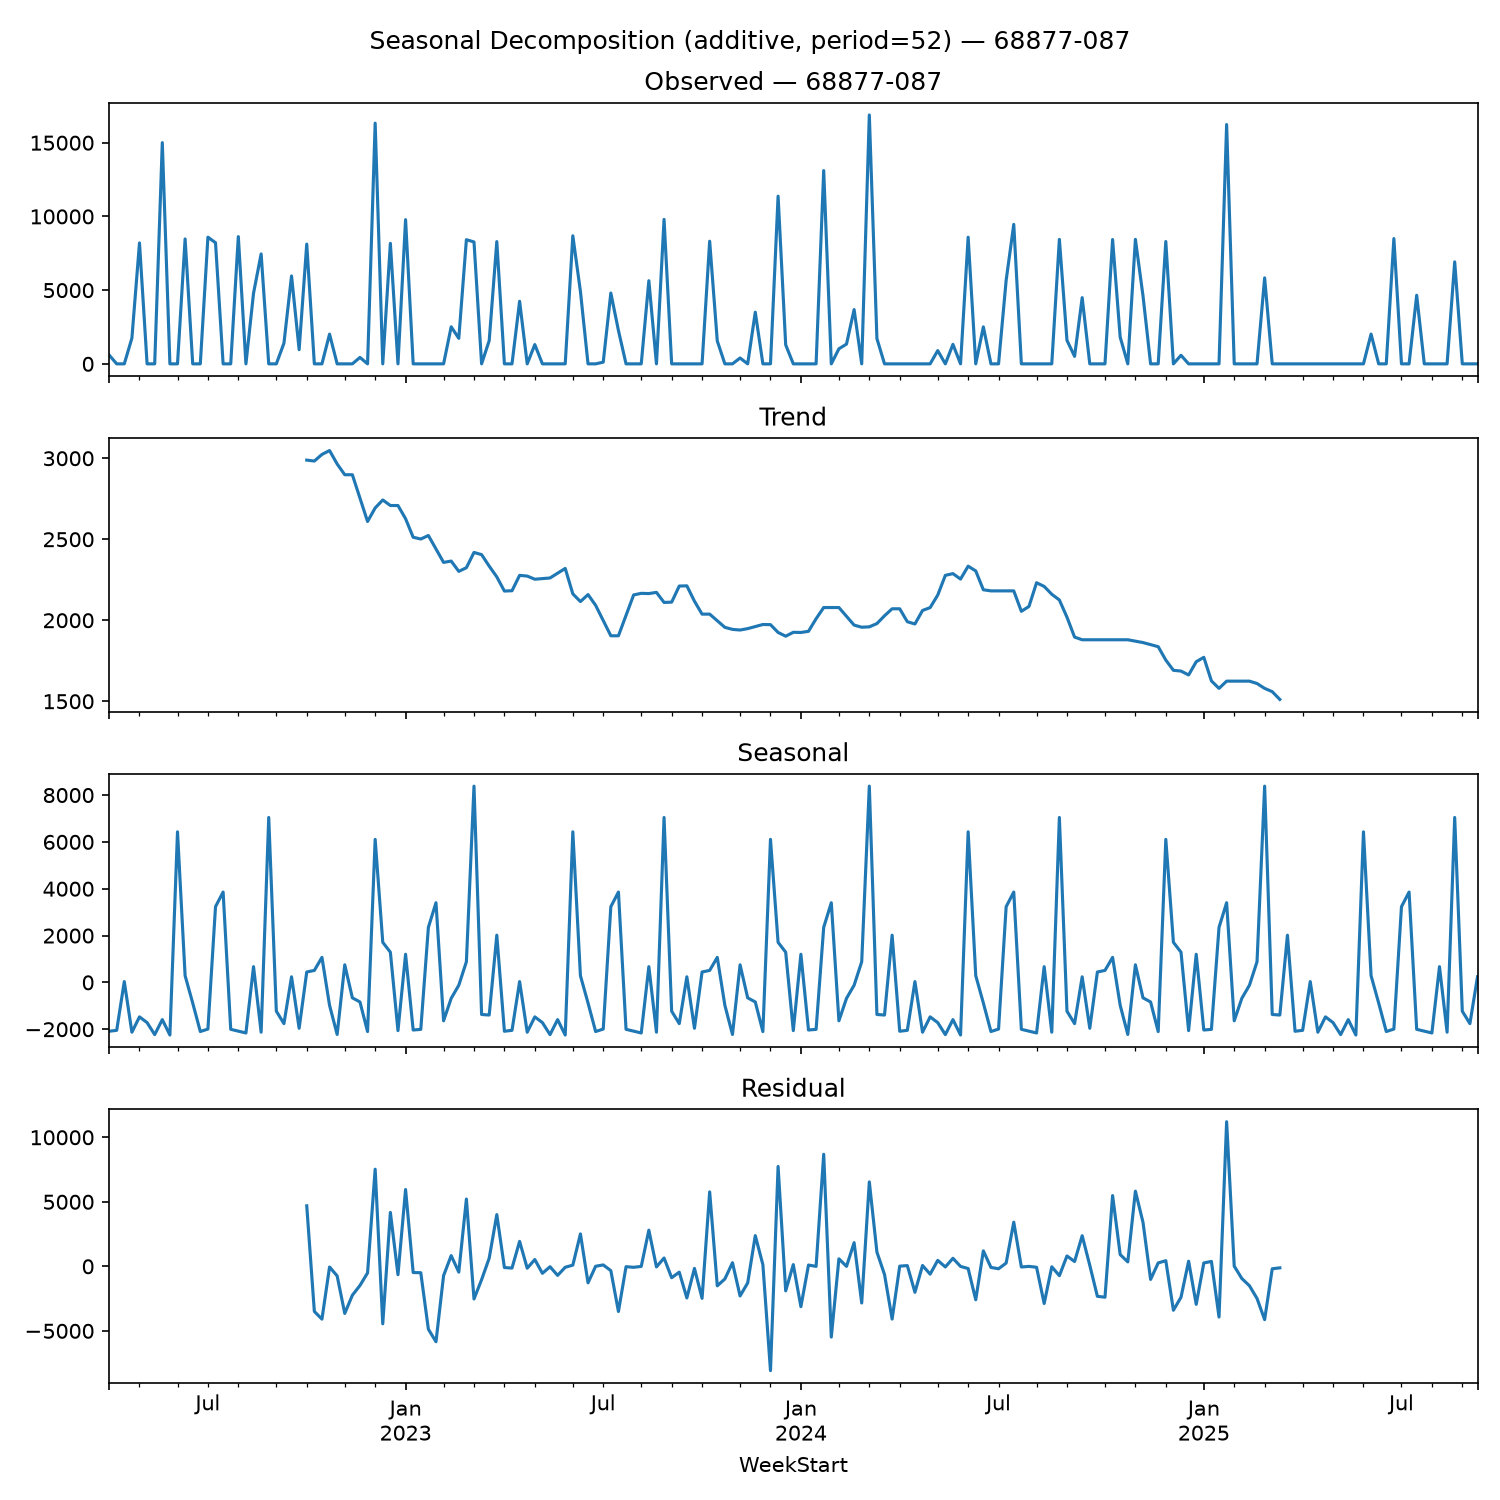

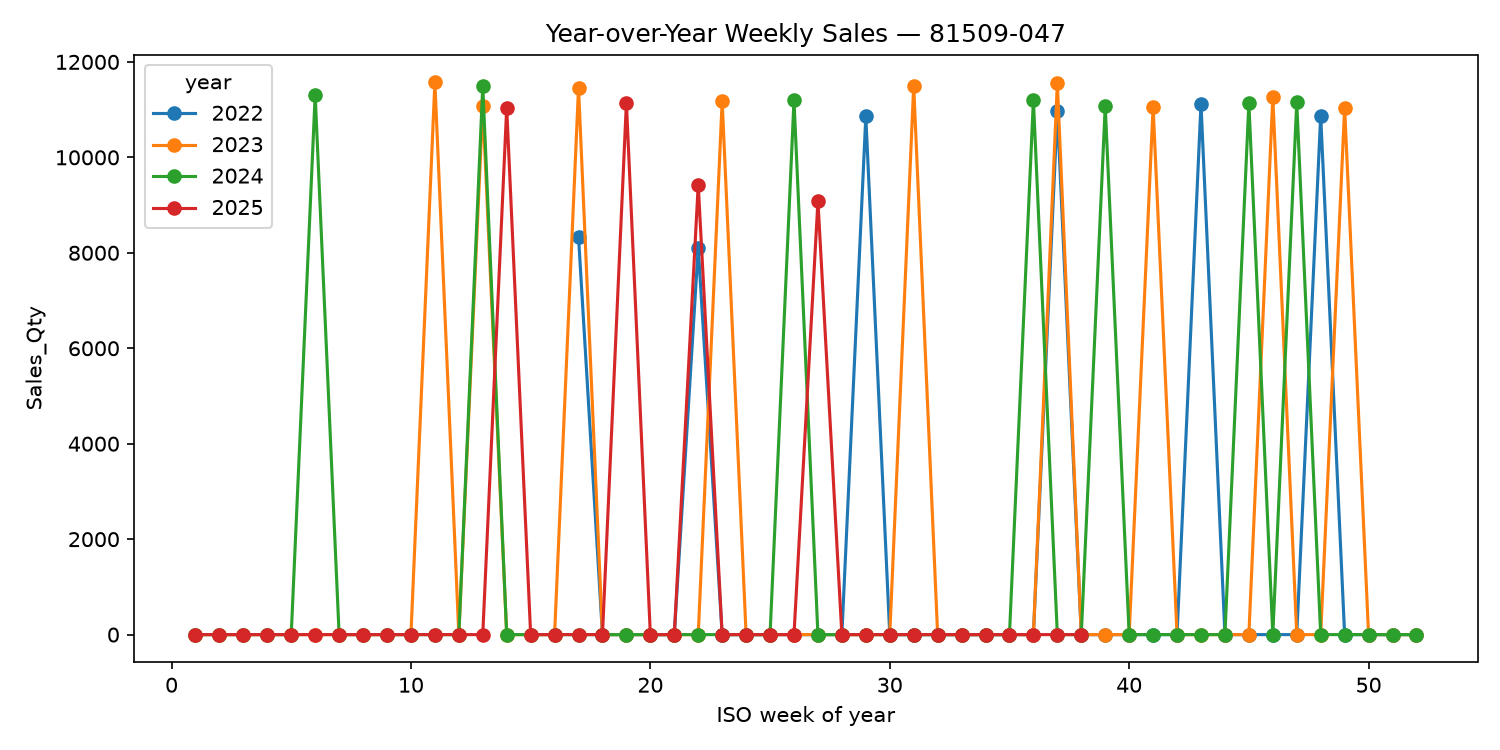

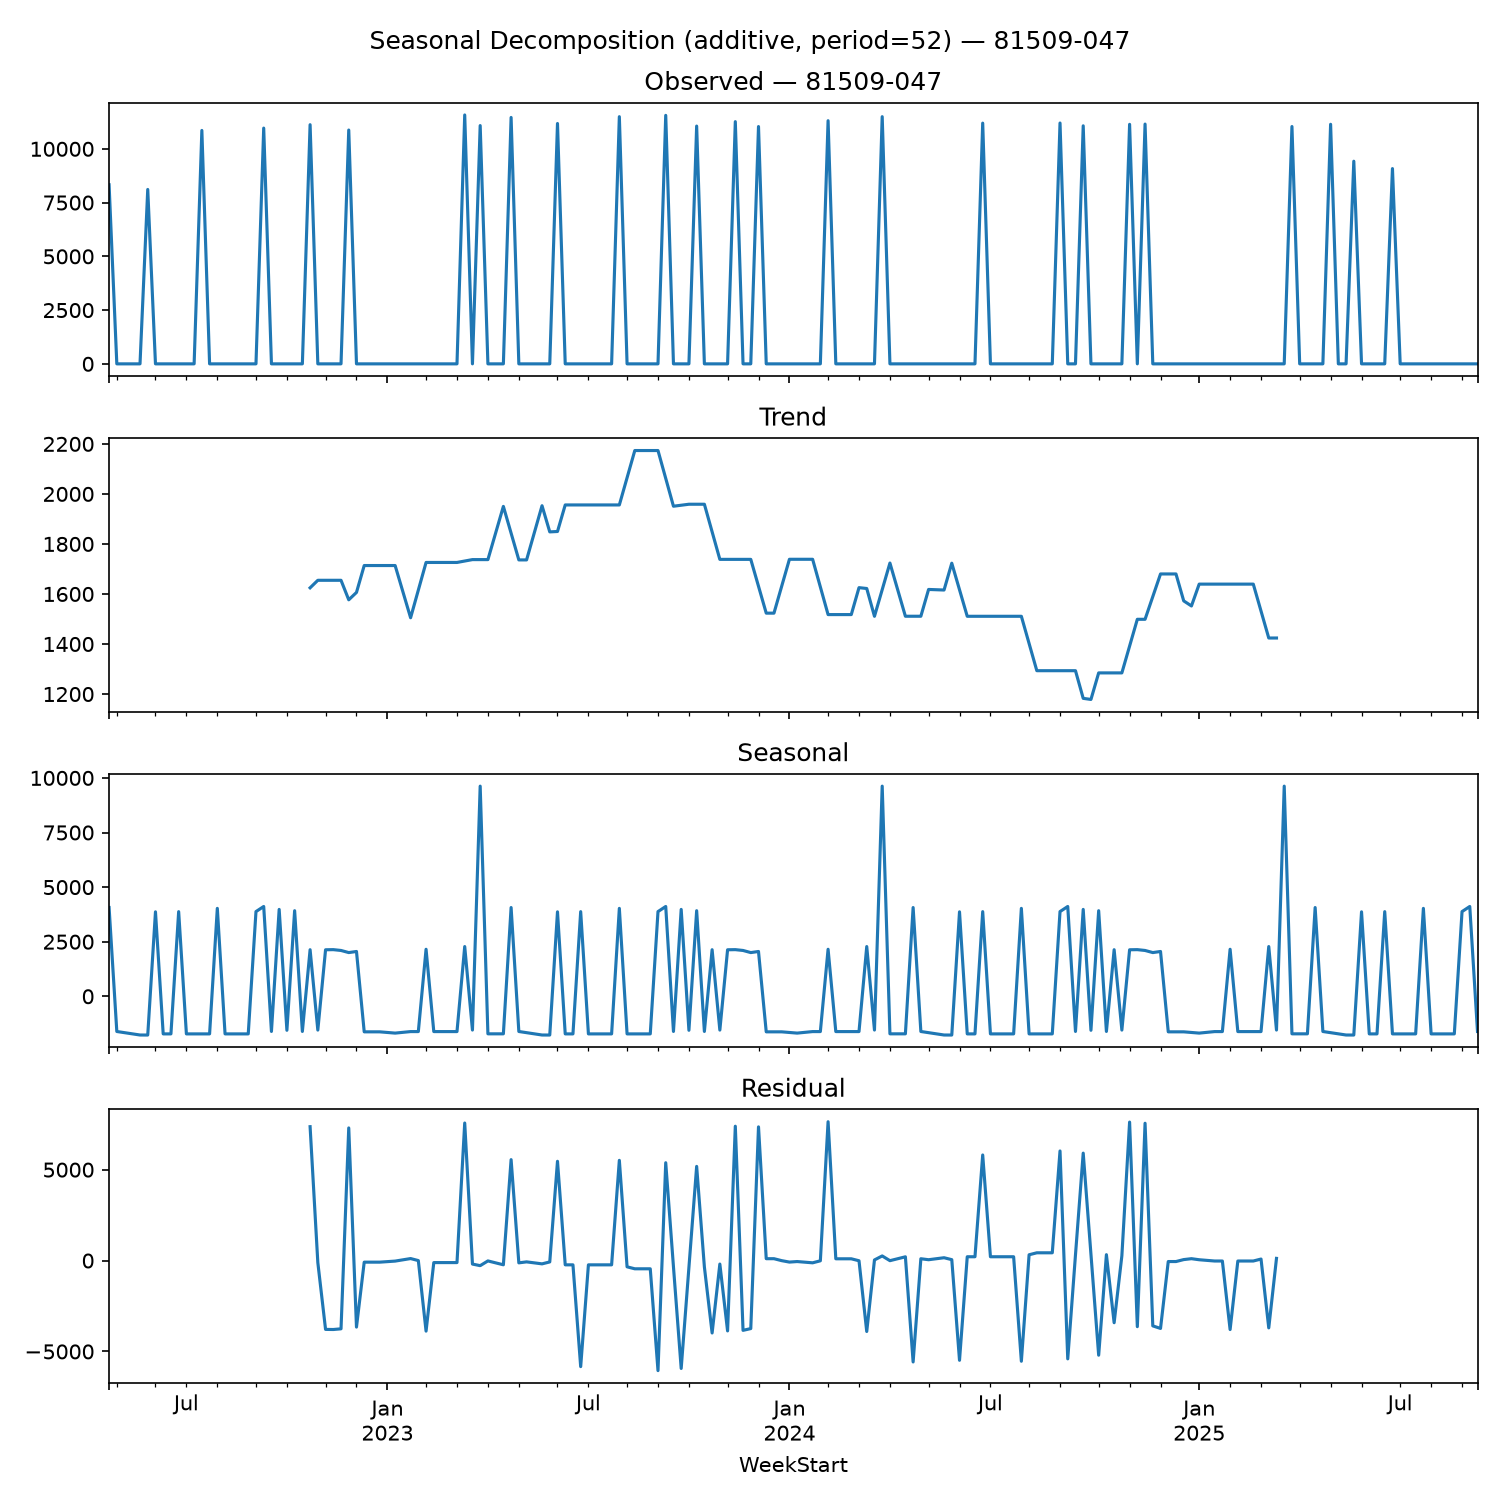

In [7]:
for product_id in product_ids:
    display(Image(filename=str(FIGURES_DIR / f"yoy_{product_id}.png")))
    display(Image(filename=str(FIGURES_DIR / f"seasonal_decompose_{product_id}.png")))
